# Proyek Klasifikasi Gambar: [Multi-class Weather Dataset]

- **Nama:** [Zahri Ramadhani]
- **Email:** [cacc179d6y0507@student.devacademy.id]
- **ID Dicoding:** [its-me-zahri]
- **URL Dataset:** [[Multi-class Weather Dataset](https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset)]

## Import Semua Packages/Library yang Digunakan

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import splitfolders
import pandas as pd
import os

## Data Preparation

### Data Loading

In [2]:
input_folder = 'multi_class_weather_dataset'
output_folder = 'weather_dataset_split'

### Data Preprocessing

#### Split Dataset

In [4]:
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.8, .1, .1))

train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')
test_dir = os.path.join(output_folder, 'test')

In [22]:
def summarize_dataset(base_path):
    sets = ['train', 'val', 'test']
    summary_data = []
    total_all_images = 0

    print("=== DATASET SUMMARY REPORT ===")
    print(f"Status: Direktori '{base_path}' ditemukan.\n")

    for s in sets:
        set_path = os.path.join(base_path, s)
        if not os.path.exists(set_path):
            print(f"Warning: Folder {s} tidak ditemukan!")
            continue
            
        classes = os.listdir(set_path)
        set_total = 0
        
        for cls in classes:
            class_path = os.path.join(set_path, cls)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                summary_data.append({
                    'Subset': s.capitalize(),
                    'Class': cls,
                    'Count': count
                })
                set_total += count
        
        total_all_images += set_total
        print(f"Total gambar pada {s.capitalize()} set: {set_total}")

    df_summary = pd.DataFrame(summary_data)
    
    print("\n--- Distribusi Per Kelas ---")
    print(df_summary.pivot(index='Class', columns='Subset', values='Count').fillna(0).astype(int))
    
    print("-" * 30)
    print(f"TOTAL KESELURUHAN GAMBAR: {total_all_images}")
    print("-" * 30)
    
summarize_dataset('weather_dataset_split')

=== DATASET SUMMARY REPORT ===
Status: Direktori 'weather_dataset_split' ditemukan.

Total gambar pada Train set: 899
Total gambar pada Val set: 111
Total gambar pada Test set: 115

--- Distribusi Per Kelas ---
Subset   Test  Train  Val
Class                    
Cloudy     30    240   30
Rain       22    172   21
Shine      26    202   25
Sunrise    37    285   35
------------------------------
TOTAL KESELURUHAN GAMBAR: 1125
------------------------------


## Modelling

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

model = Sequential([
    # Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    # Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Layer 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            print('\nAkurasi training dan validasi telah mencapai > 95%')
            self.model.stop_training = True

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    verbose=1,
    callbacks=[myCallback(), early_stop, reduce_lr]
)

Found 899 images belonging to 4 classes.
Found 111 images belonging to 4 classes.


d:\Kuliah\DBS Fondation\Machine-Learning\Submission\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - accuracy: 0.5606 - loss: 0.9710 - val_accuracy: 0.6577 - val_loss: 0.7758 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.7386 - loss: 0.6484 - val_accuracy: 0.7748 - val_loss: 0.6421 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.7875 - loss: 0.5201 - val_accuracy: 0.8649 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.8154 - loss: 0.4804 - val_accuracy: 0.7477 - val_loss: 0.5612 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.8220 - loss: 0.4447 - val_accuracy: 0.8559 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.8420 - loss: 0.4357 - val_accuracy: 0.9009 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.8454 - loss: 0.3930 - 

In [ ]:
test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"\n--- HASIL EVALUASI AKHIR (TEST SET) ---")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

Found 115 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9478 - loss: 0.2093

--- HASIL EVALUASI AKHIR (TEST SET) ---
Test Accuracy: 94.78%
Test Loss    : 0.2093


## Evaluasi dan Visualisasi

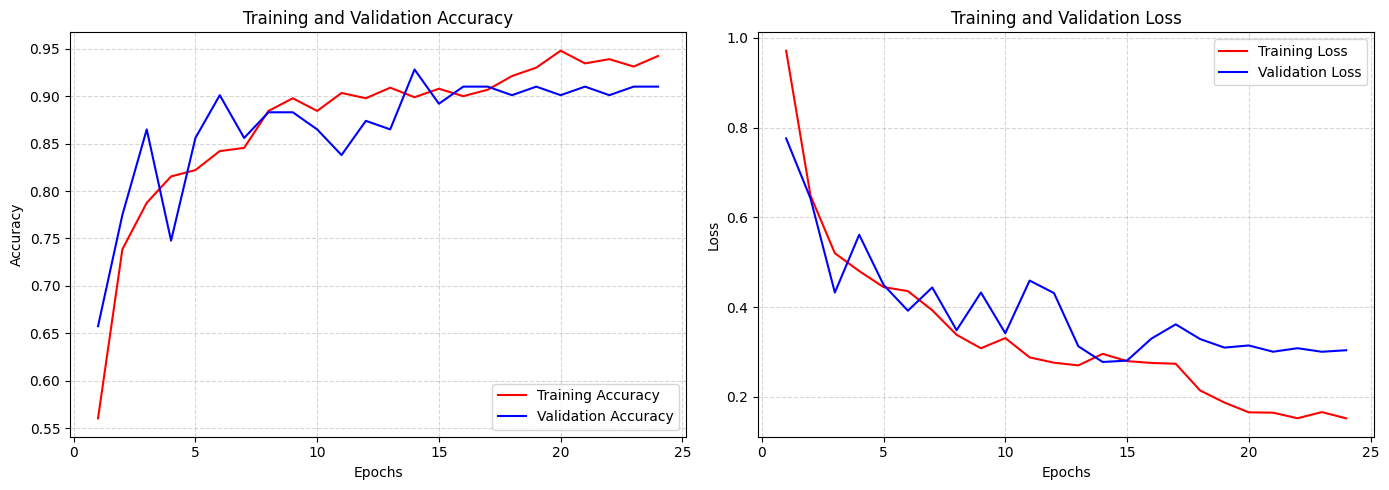


Final Training Accuracy   : 94.22%
Final Validation Accuracy : 90.99%
Final Training Loss       : 0.1524
Final Validation Loss     : 0.3040


In [12]:
def plot_train_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Training Accuracy   : {acc[-1]*100:.2f}%")
    print(f"Final Validation Accuracy : {val_acc[-1]*100:.2f}%")
    print(f"Final Training Loss       : {loss[-1]:.4f}")
    print(f"Final Validation Loss     : {val_loss[-1]:.4f}")

plot_train_history(history)

## Konversi Model

In [ ]:
# 1. SavedModel Format
saved_model_path = 'weather_model_saved'
model.export(saved_model_path)
print(f"Model SavedModel berhasil disimpan di: {saved_model_path}")

# 2. TFLite Format
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open('weather_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model TFLite berhasil dibuat: weather_model.tflite")

# 3. TFJS format
# Untuk mengkonversi model ke format TFJS, saya menggunakan colab karena local tidak support. Langkah untuk mengkonversi model ke format TFJS dengan colab adalah:

# !pip install tensorflowjs --quiet
# !unzip sample_data/weather_model_saved.zip

# input_dir = 'weather_model_saved'
# output_dir = 'tfjs_model'
# !tensorflowjs_converter \
#     --input_format=tf_saved_model \
#     {input_dir} \
#     {output_dir}

# !zip -r tfjs_model.zip tfjs_model

INFO:tensorflow:Assets written to: weather_model_saved\assets


INFO:tensorflow:Assets written to: weather_model_saved\assets


Saved artifact at 'weather_model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_31')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2387091156736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091229680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091234256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091232320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091236016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091233376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091237072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091234432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091234080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091237248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2387091232144: TensorSpec(sh

## Inference (Optional)

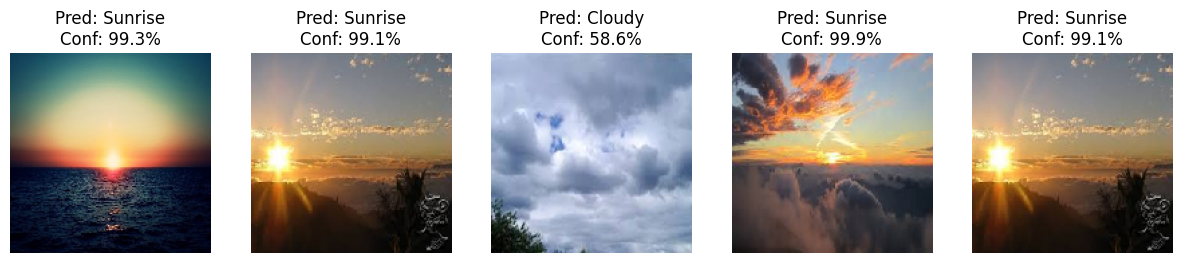

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def show_inference_results(test_dir, model, num_images=5):
    class_indices = train_generator.class_indices
    labels = {v: k for k, v in class_indices.items()}
    
    all_test_images = []
    for root, dirs, files in os.walk(test_dir):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_test_images.append(os.path.join(root, file))
    
    sample_images = np.random.choice(all_test_images, num_images)
    
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        img = image.load_img(img_path, target_size=(150, 150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0
        
        pred = model.predict(img_array, verbose=0)
        result = labels[np.argmax(pred)]
        confidence = np.max(pred) * 100
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Pred: {result}\nConf: {confidence:.1f}%")
        plt.axis('off')
    plt.show()

show_inference_results(test_dir, model)